# **Mounting Drive**

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Step 1: Data Loading & Initial Inspection**

1. Import Libraries

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

2. Load the dataset from the CSV file

In [25]:
df = pd.read_csv('/content/framingham.csv')

3. Check the dataset dimensions (Rows, Columns)

In [26]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4240, 16)


4. Inspect column data types and non-null counts

In [27]:
print("\n--- Dataset Summary ---")
df.info()


--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usag

5. Check the count of missing values per column

In [28]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


6. Preview the first 5 rows

In [29]:
print("\n--- First 5 Rows ---")
df.head()


--- First 5 Rows ---


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# **Step 2: EDA & Data Cleaning**

1. Create a copy of the dataframe for cleaning

In [30]:
df_clean = df.copy()

2. Impute continuous numerical columns with Median

In [31]:
numerical_cols_with_na = ['glucose', 'totChol', 'BMI', 'heartRate', 'cigsPerDay']
for col in numerical_cols_with_na:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

3. Impute categorical columns with Mode

In [32]:
categorical_cols_with_na = ['BPMeds', 'education']
for col in categorical_cols_with_na:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

4. Verify that no missing values remain

In [33]:
print("--- Missing Values After Cleaning ---")
print(df_clean.isnull().sum())

--- Missing Values After Cleaning ---
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


5. Visualize distributions for outlier detection

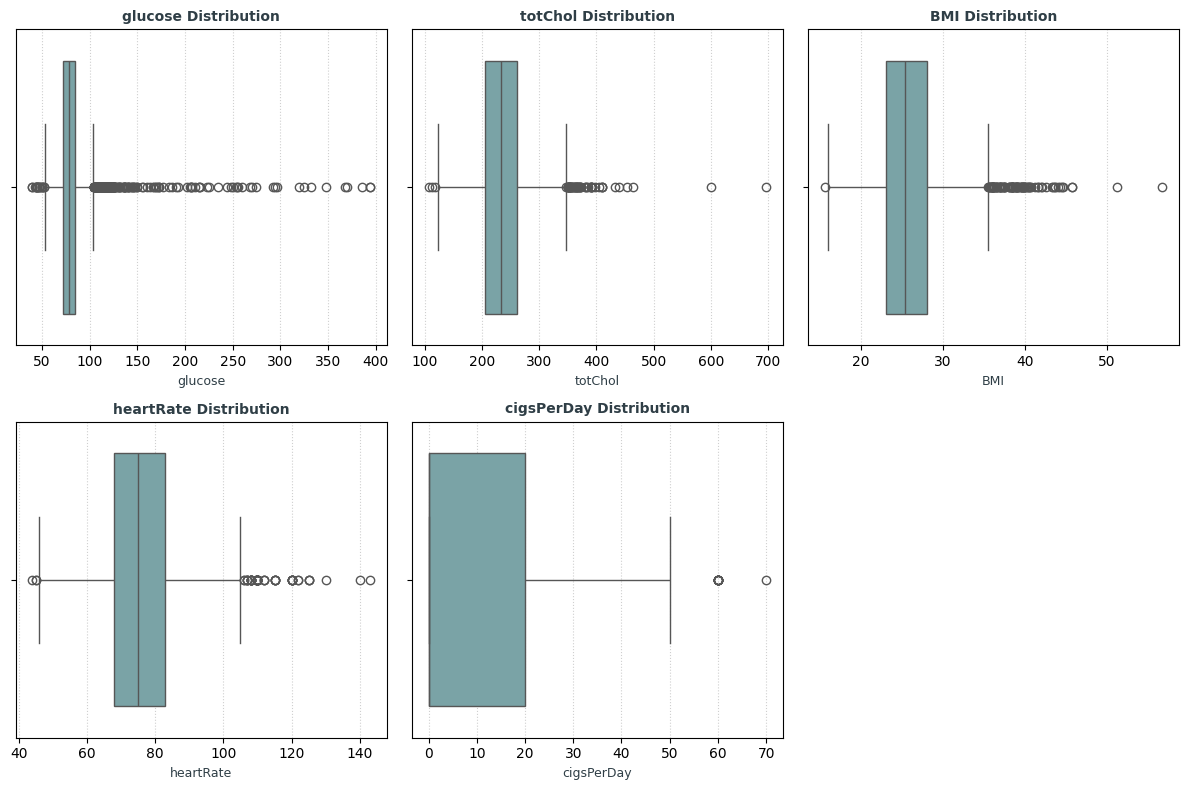

In [56]:
teal_gray_cmap = LinearSegmentedColormap.from_list("TealGray", ["#EAECEE", "#73A9AD", "#005F73"])
plt.figure(figsize=(12,8))
for i, col in enumerate(numerical_cols_with_na, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x=df_clean[col], color="#73A9AD")
    plt.title(f"{col} Distribution", fontsize=10, fontweight='bold', color='#2F3E46')
    plt.xlabel(col, fontsize=9, color='#2F3E46')
    plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# **Step 3: Feature Preparation & Scaling**

1. Separate target variable (y) from feature matrix (X)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=['diabetes'])
y = df_clean['diabetes']

2. Split dataset into 80% Training and 20% Testing sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")

Training set size: 3392 samples
Testing set size:  848 samples


3. Fit the scaler on training data ONLY, then transform both train & test sets

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures successfully scaled!")


Features successfully scaled!


4. Visualization: Feature Distributions After Scaling

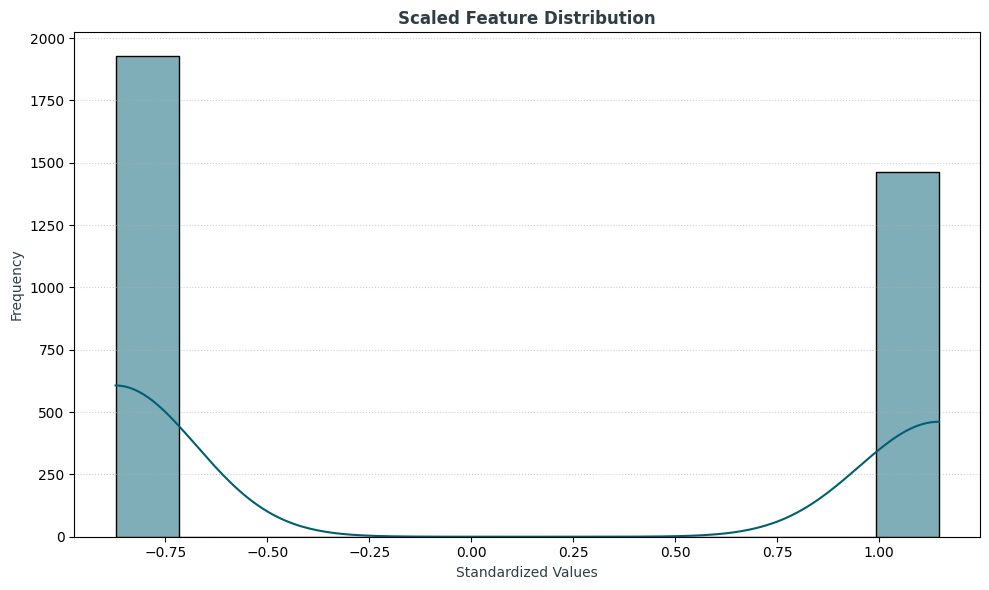

In [64]:
teal_gray_cmap = LinearSegmentedColormap.from_list("TealGray", ["#EAECEE", "#73A9AD", "#005F73"])

plt.figure(figsize=(10,6))
sns.histplot(X_train_scaled[:,0], kde=True, color="#005F73")
plt.title("Scaled Feature Distribution", fontsize=12, fontweight='bold', color='#2F3E46')
plt.xlabel("Standardized Values", fontsize=10, color='#2F3E46')
plt.ylabel("Frequency", fontsize=10, color='#2F3E46')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# **Step 4: Model Training & Handling Imbalanced Data**

1. Train Standard Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
model_standard = LogisticRegression(random_state=42)
model_standard.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

2. Train Balanced Logistic Regression (Handles class imbalance)

In [38]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)
model_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

3. Make predictions on the test set

In [39]:
y_pred_standard = model_standard.predict(X_test_scaled)
y_pred_balanced = model_balanced.predict(X_test_scaled)

print("=== Standard Model Classification Report ===")
print(classification_report(y_test, y_pred_standard))

print("\n=== Balanced Model Classification Report ===")
print(classification_report(y_test, y_pred_balanced))

=== Standard Model Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       826
           1       1.00      0.64      0.78        22

    accuracy                           0.99       848
   macro avg       1.00      0.82      0.89       848
weighted avg       0.99      0.99      0.99       848


=== Balanced Model Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.92      0.96       826
           1       0.21      0.82      0.34        22

    accuracy                           0.92       848
   macro avg       0.60      0.87      0.65       848
weighted avg       0.97      0.92      0.94       848



4. ROC Curve

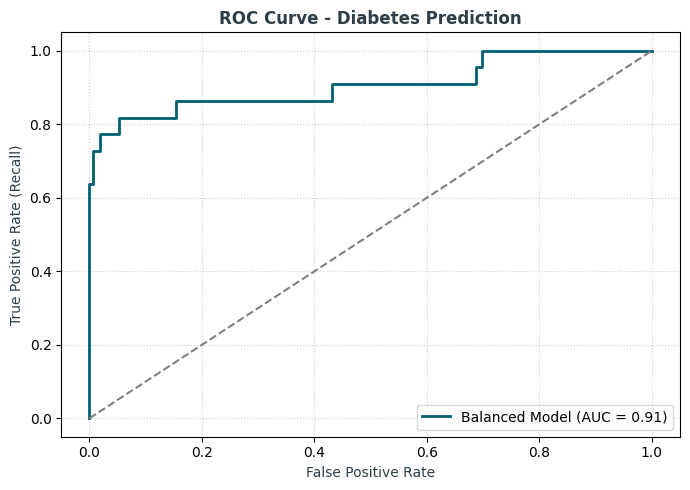

In [58]:
y_probs = model_balanced.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

teal_gray_cmap = LinearSegmentedColormap.from_list("TealGray", ["#EAECEE", "#73A9AD", "#005F73"])

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color="#005F73", lw=2, label=f'Balanced Model (AUC = {auc_score:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.title("ROC Curve - Diabetes Prediction", fontsize=12, fontweight='bold', color='#2F3E46')
plt.xlabel("False Positive Rate", fontsize=10, color='#2F3E46')
plt.ylabel("True Positive Rate (Recall)", fontsize=10, color='#2F3E46')
plt.legend(loc='lower right')
plt.grid(axis='both', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


5. Confusion Matrix Heatmap (Balanced Model)

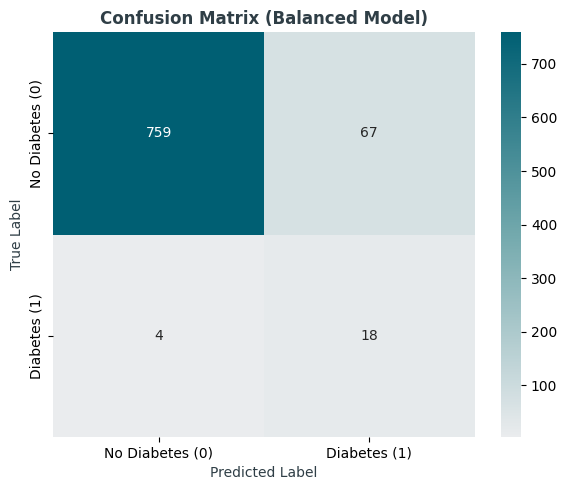

In [59]:
 cm = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_gray_cmap,
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.title("Confusion Matrix (Balanced Model)", fontsize=12, fontweight='bold', color='#2F3E46')
plt.xlabel("Predicted Label", fontsize=10, color='#2F3E46')
plt.ylabel("True Label", fontsize=10, color='#2F3E46')
plt.tight_layout()
plt.show()

# **Step 5: Model Evaluation & Feature Importance**

1. Import Libraries

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

2. Confusion Matrix (Balanced Model)

In [61]:
cm = confusion_matrix(y_test, y_pred_balanced)

3. Colormap

In [ ]:
teal_gray_cmap = LinearSegmentedColormap.from_list("TealGray", ["#EAECEE", "#73A9AD", "#005F73"])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_gray_cmap,
            xticklabels=['No Diabetes (0)', 'Diabetes (1)'],
            yticklabels=['No Diabetes (0)', 'Diabetes (1)'])
plt.title("Confusion Matrix (Balanced Model)", fontsize=12, fontweight='bold', color='#2F3E46')
plt.xlabel("Predicted Label", fontsize=10, color='#2F3E46')
plt.ylabel("True Label", fontsize=10, color='#2F3E46')
plt.tight_layout()
plt.show()

4. Feature Importance (Logistic Regression Coefficients)

In [62]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_balanced.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Feature Weights (Impact on Diabetes Risk) ---")
print(coef_df)


--- Feature Weights (Impact on Diabetes Risk) ---
            Feature  Coefficient
13          glucose     1.531658
9             sysBP     0.393185
7      prevalentHyp     0.251001
1               age     0.204655
12        heartRate     0.108328
0              male     0.103873
4        cigsPerDay     0.099479
14       TenYearCHD     0.083350
5            BPMeds     0.045481
11              BMI     0.006760
8           totChol    -0.006465
2         education    -0.008952
3     currentSmoker    -0.080998
6   prevalentStroke    -0.304303
10            diaBP    -0.382384


5. Horizontal Bar Plot

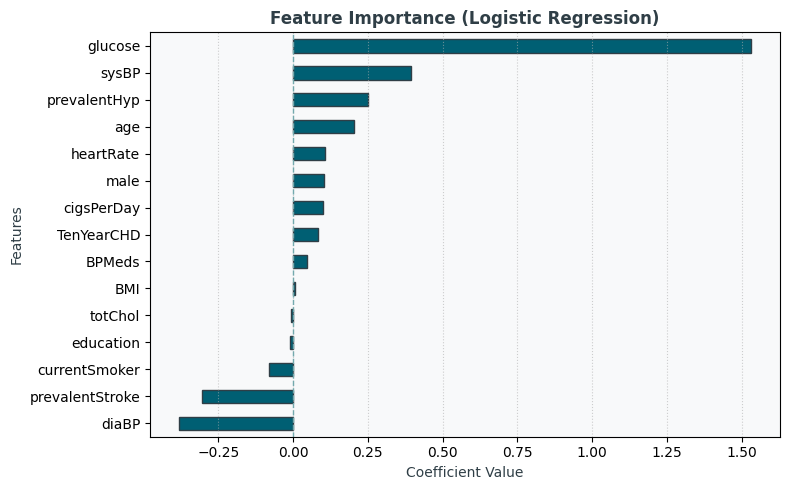

In [63]:
coefficients = pd.Series(model_balanced.coef_[0], index=X.columns)
sorted_coeffs = coefficients.sort_values()

plt.figure(figsize=(8,5))
sorted_coeffs.plot(kind='barh', color="#005F73", edgecolor='#2F3E46')
plt.title("Feature Importance (Logistic Regression)", fontsize=12, fontweight='bold', color='#2F3E46')
plt.xlabel("Coefficient Value", fontsize=10, color='#2F3E46')
plt.ylabel("Features", fontsize=10, color='#2F3E46')
plt.axvline(x=0, color='#73A9AD', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.gca().set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()